# Library and Data Imports and Standardization

In [ ]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Import the classification report
from sklearn.metrics import classification_report

# Import the f1 score
from sklearn.metrics import f1_score

# Import train test split
from sklearn.model_selection import train_test_split

# Import KFold
from sklearn.model_selection import KFold

from matplotlib.cm import get_cmap
cmap = get_cmap('hot')
middle_color = cmap(0.5)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import the datasets
convabuse = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/convabuse_imbalanced.csv')
dynamically_generated_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/dynamically_generated_hate_speech_dataset_imbalanced.csv')
online_abusive_attacks = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/online_abusive_attacks_class_imbalanced.csv')
us_elections_2020_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/us_elections_2020_hate_speech_imbalanced.csv')
mlma_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/MLMA_hate_speech_imbalanced.csv')

In [ ]:
convabuse.head()

,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,7,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,1,0
2,7,0,0,0,0,0,0,0,0
3,7,1,0,0,0,0,0,0,0
4,7,0,0,0,0,0,0,0,0


In [ ]:
convabuse_X = convabuse.drop("abuse_level", axis=1)
convabuse_y = convabuse["abuse_level"]

In [ ]:
dynamically_generated_hate_speech.head()

,label,type,annotator,target_groups,original
0,1.0,0,3,0,1
1,1.0,0,3,0,1
2,1.0,0,18,0,1
3,1.0,0,16,0,1
4,1.0,0,7,0,1


In [ ]:
dghs_X = dynamically_generated_hate_speech.drop("label", axis=1)
dghs_y = dynamically_generated_hate_speech["label"]

In [ ]:
online_abusive_attacks.head()

,Toxic parent tweets,Toxic replies,Toxic Level
0,0.0,0.0,0
1,67.0,13.0,2
2,28.0,45.0,2
3,47.0,49.0,2
4,97.0,7.0,3


In [ ]:
oaa_X = online_abusive_attacks.drop("Toxic Level", axis=1)
oaa_y = online_abusive_attacks["Toxic Level"]

In [ ]:
us_elections_2020_hate_speech.head()

,Trump,Biden,West,HOF
0,1,0,1,0
1,1,0,1,0
2,-1,0,1,0
3,0,0,1,0
4,0,1,1,0


In [ ]:
us2020hs_X = us_elections_2020_hate_speech.drop("HOF", axis=1)
us2020hs_y = us_elections_2020_hate_speech["HOF"]

In [ ]:
mlma_hate_speech.head()

,shock_annotator_sentiment,anger_annotator_sentiment,confusion_annotator_sentiment,sadness_annotator_sentiment,indifference_annotator_sentiment,disgust_annotator_sentiment,fear_annotator_sentiment,implicit,explicit,Abusive,Not Abusive,Very Abusive,Very Strongly Abusive,target_groups
0,1,0,0,0,0,0,0,1,0,0,1,1,0,1
1,0,1,1,1,1,1,0,1,0,1,0,0,0,0
2,0,0,0,0,1,0,0,1,0,1,0,0,0,0
3,0,0,0,0,1,0,0,0,1,0,1,0,0,1
4,0,0,0,0,1,0,0,1,0,0,1,0,0,1


In [ ]:
mlma_hate_speech_X = mlma_hate_speech.drop("target_groups", axis=1)
mlma_hate_speech_y = mlma_hate_speech["target_groups"]

# Linear Modeling

In [ ]:
# Get only the numeric features for each dataset
convabuse_X_numeric = convabuse_X.select_dtypes(include=np.number)
dghs_X_numeric = dghs_X.select_dtypes(include=np.number)
oaa_X_numeric = oaa_X.select_dtypes(include=np.number)
us2020hs_X_numeric = us2020hs_X.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric = mlma_hate_speech_X.select_dtypes(include=np.number)

In [ ]:
# Use standard scaler on the Convabuse data
convabuse_scaler = StandardScaler()
convabuse_X_scaled = convabuse_scaler.fit_transform(convabuse_X_numeric)
convabuse_X_scaled = pd.DataFrame(convabuse_X_scaled, columns=convabuse_X_numeric.columns)

In [ ]:
# Use standard scaler on the Dynamically Generated Hate Speech X data
dghs_scaler = StandardScaler()
dghs_X_scaled = dghs_scaler.fit_transform(dghs_X_numeric)
dghs_X_scaled = pd.DataFrame(dghs_X_scaled, columns=dghs_X_numeric.columns)

In [ ]:
# Use standard scaler on the Online Abusive Attacks X data
oaa_scaler = StandardScaler()
oaa_X_scaled = oaa_scaler.fit_transform(oaa_X_numeric)
oaa_X_scaled = pd.DataFrame(oaa_X_scaled, columns=oaa_X_numeric.columns)

In [ ]:
# Use standard scaler on the US elections 2020 hate speech X data
us2020hs_scaler = StandardScaler()
us2020hs_X_scaled = us2020hs_scaler.fit_transform(us2020hs_X_numeric)
us2020hs_X_scaled = pd.DataFrame(us2020hs_X_scaled, columns=us2020hs_X_numeric.columns)

In [ ]:
# Use standard scaler on the MLMS hate speech X data
mlma_hate_speech_scaler = StandardScaler()
mlma_hate_speech_X_scaled = mlma_hate_speech_scaler.fit_transform(mlma_hate_speech_X_numeric)
mlma_hate_speech_X_scaled = pd.DataFrame(mlma_hate_speech_X_scaled, columns=mlma_hate_speech_X_numeric.columns)

In [ ]:
for columns in [convabuse_X_numeric.columns, dghs_X_numeric.columns, oaa_X_numeric.columns, us2020hs_X_numeric.columns, mlma_hate_speech_X_numeric.columns]:
  print(columns)

Index(['annotator_id', 'bot', 'generalised', 'individual', 'system',
       'explicit', 'implicit', 'target_groups'],
      dtype='object')
Index(['type', 'annotator', 'target_groups', 'original'], dtype='object')
Index(['Toxic parent tweets', 'Toxic replies'], dtype='object')
Index(['Trump', 'Biden', 'West'], dtype='object')
Index(['shock_annotator_sentiment', 'anger_annotator_sentiment',
       'confusion_annotator_sentiment', 'sadness_annotator_sentiment',
       'indifference_annotator_sentiment', 'disgust_annotator_sentiment',
       'fear_annotator_sentiment', 'implicit', 'explicit', 'Abusive',
       'Not Abusive', 'Very Abusive', 'Very Strongly Abusive'],
      dtype='object')


In [ ]:
# Train test split for each dataset
convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test = train_test_split(convabuse_X_scaled, convabuse_y, test_size=0.2, random_state=42, stratify=convabuse_y)
dghs_X_train, dghs_X_test, dghs_y_train, dghs_y_test = train_test_split(dghs_X_scaled, dghs_y, test_size=0.2, random_state=42, stratify=dghs_y)
oaa_X_train, oaa_X_test, oaa_y_train, oaa_y_test = train_test_split(oaa_X_scaled, oaa_y, test_size=0.2, random_state=42, stratify=oaa_y)
us2020hs_X_train, us2020hs_X_test, us2020hs_y_train, us2020hs_y_test = train_test_split(us2020hs_X_scaled, us2020hs_y, test_size=0.2, random_state=42, stratify=us2020hs_y)
mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test = train_test_split(mlma_hate_speech_X_scaled, mlma_hate_speech_y, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y)

In [ ]:
regularizers = ["l1", "l2"]

In [ ]:
solvers = ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]

In [ ]:
l1_ratio_list = [0.5]

In [ ]:
logistic_regression_model_results = []

In [ ]:
balance = "Imbalanced"

## Convabuse Logistic Regression

In [ ]:
convabuse_results_list = []

# Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Convabuse dataset
for regularizer in regularizers:
  for solver in solvers:
    if regularizer == "l1" and solver not in ["liblinear", "saga"]:
      continue
    convabuse_logistic_regression = LogisticRegression(penalty=regularizer, solver=solver, random_state=42)
    convabuse_logistic_regression.fit(convabuse_X_train, convabuse_y_train)
    # Predict the target variable for the test set
    convabuse_y_pred = convabuse_logistic_regression.predict(convabuse_X_test)

    # Calculate the accuracy of the model
    convabuse_accuracy = accuracy_score(convabuse_y_test, convabuse_y_pred)
    convabuse_f1_score = f1_score(convabuse_y_test, convabuse_y_pred, average='weighted') # Weighted average due to multiclass
    convabuse_results_list.append(("Convabuse", regularizer, solver, convabuse_accuracy, convabuse_f1_score, 0))
    print(f"Regularizer: {regularizer}, Solver: {solver}, Accuracy: {convabuse_accuracy}, F1-score: {convabuse_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.8855325914149443, F1-score: 0.8520266948557892
Regularizer: l1, Solver: saga, Accuracy: 0.8855325914149443, F1-score: 0.8520266948557892
Regularizer: l2, Solver: lbfgs, Accuracy: 0.8855325914149443, F1-score: 0.8520266948557892
Regularizer: l2, Solver: liblinear, Accuracy: 0.8855325914149443, F1-score: 0.8520266948557892
Regularizer: l2, Solver: newton-cg, Accuracy: 0.8855325914149443, F1-score: 0.8520266948557892
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.8855325914149443, F1-score: 0.8520266948557892
Regularizer: l2, Solver: sag, Accuracy: 0.8855325914149443, F1-score: 0.8520266948557892
Regularizer: l2, Solver: saga, Accuracy: 0.8855325914149443, F1-score: 0.8520266948557892


In [ ]:
for ratio in l1_ratio_list:
    convabuse_logistic_regression = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=ratio, random_state=42)
    convabuse_logistic_regression.fit(convabuse_X_train, convabuse_y_train)
    # Predict the target variable for the test set
    convabuse_y_pred = convabuse_logistic_regression.predict(convabuse_X_test)

    # Calculate the accuracy of the model
    convabuse_accuracy = accuracy_score(convabuse_y_test, convabuse_y_pred)
    convabuse_f1_score = f1_score(convabuse_y_test, convabuse_y_pred, average='weighted')
    convabuse_results_list.append(("Convabuse", "elasticnet", "saga", convabuse_accuracy, convabuse_f1_score, ratio))
    print(f"Regularizer: elasticnet, l1_ratio: {ratio}, Accuracy: {convabuse_accuracy}, F1-score: {convabuse_f1_score}")

Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.8855325914149443, F1-score: 0.8520266948557892


In [ ]:
# Convert the results list into a dataframe
convabuse_results = pd.DataFrame(convabuse_results_list, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio"])
convabuse_results

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,Convabuse,l1,liblinear,0.885533,0.852027,0.0
1,Convabuse,l1,saga,0.885533,0.852027,0.0
2,Convabuse,l2,lbfgs,0.885533,0.852027,0.0
3,Convabuse,l2,liblinear,0.885533,0.852027,0.0
4,Convabuse,l2,newton-cg,0.885533,0.852027,0.0
5,Convabuse,l2,newton-cholesky,0.885533,0.852027,0.0
6,Convabuse,l2,sag,0.885533,0.852027,0.0
7,Convabuse,l2,saga,0.885533,0.852027,0.0
8,Convabuse,elasticnet,saga,0.885533,0.852027,0.5


In [ ]:
convabuse_best_model_params = convabuse_results.loc[convabuse_results["Accuracy"].idxmax()]
convabuse_best_model_params

,0
Dataset,Convabuse
Regularizer,l1
Solver,liblinear
Accuracy,0.885533
F1-score,0.852027
Ratio,0.0


In [ ]:
# Use the best parameters to create a new best model
convabuse_best_model = LogisticRegression(penalty=convabuse_best_model_params["Regularizer"], solver=convabuse_best_model_params["Solver"], random_state=42)
convabuse_best_model.fit(convabuse_X_train, convabuse_y_train)

# Predict the target variable for the test set
convabuse_y_pred = convabuse_best_model.predict(convabuse_X_test)

# Calculate the accuracy of the model
convabuse_accuracy = accuracy_score(convabuse_y_test, convabuse_y_pred)
convabuse_f1_score = f1_score(convabuse_y_test, convabuse_y_pred, average='weighted')

print(f"Regularizer: {convabuse_best_model_params['Regularizer']}, Solver: {convabuse_best_model_params['Solver']}, Accuracy: {convabuse_accuracy}, F1-score: {convabuse_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.8855325914149443, F1-score: 0.8520266948557892


In [ ]:
# Get the best correlated feature with the target variable
convabuse_best_correlated_feature = convabuse_X_train.corrwith(convabuse_y_train).abs().idxmax()
convabuse_best_correlated_feature

'system'

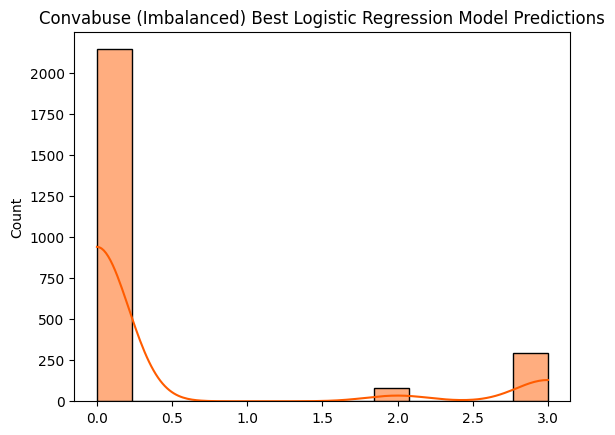

In [ ]:
# Plot the predictions that were generated as a histogram using seaborn colored by correct vs incorrect predictions
sns.histplot(convabuse_y_pred, kde=True, color=middle_color)
plt.title(f"Convabuse ({balance}) Best Logistic Regression Model Predictions")
plt.show()

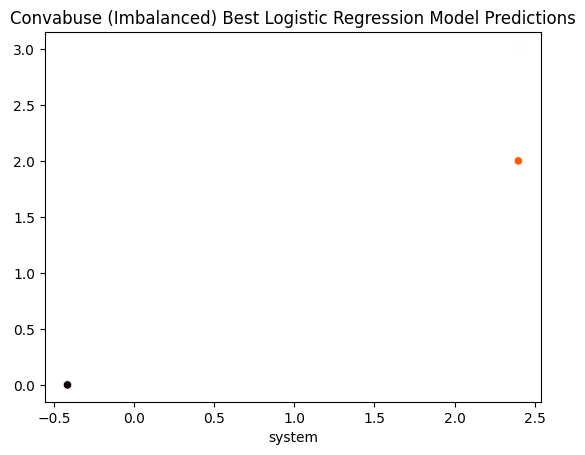

In [ ]:
# Plot the predictions that were generated as a scatterplot plotted against the best correlated feature
sns.scatterplot(x=convabuse_X_test[convabuse_best_correlated_feature], y=convabuse_y_pred, c=convabuse_y_test, cmap='hot')
plt.title(f"Convabuse ({balance}) Best Logistic Regression Model Predictions")
plt.show()

In [ ]:
# Classification report for the best model
print(classification_report(convabuse_y_test, convabuse_y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2013
           1       0.00      0.00      0.00       132
           2       0.76      0.40      0.52       150
           3       0.53      0.90      0.66       173
           4       0.00      0.00      0.00        48

    accuracy                           0.89      2516
   macro avg       0.44      0.46      0.43      2516
weighted avg       0.83      0.89      0.85      2516



In [ ]:
# Confusion matrix for the best model
convabuse_confusion_matrix = pd.crosstab(convabuse_y_test, convabuse_y_pred, rownames=["Actual"], colnames=["Predicted"])
convabuse_confusion_matrix

Predicted,0,2,3
Actual,,,
0,2013,0,0
1,129,1,2
2,0,60,90
3,0,18,155
4,0,0,48


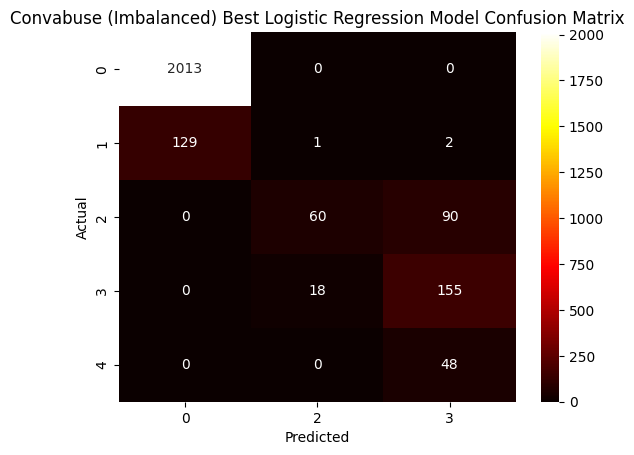

In [ ]:
# Heatmap to visualize the confusion matrix
sns.heatmap(convabuse_confusion_matrix, annot=True, fmt="d", cmap="hot")
plt.title(f"Convabuse ({balance}) Best Logistic Regression Model Confusion Matrix")
plt.show()

In [ ]:
# Calculate the feature importances
convabuse_feature_importances = pd.DataFrame({"Feature": convabuse_X_train.columns, "Importance": convabuse_best_model.coef_[0]})
convabuse_feature_importances = convabuse_feature_importances.sort_values(by="Importance", ascending=False)
convabuse_feature_importances

,Feature,Importance
1,bot,0.577720
2,generalised,0.000000
3,individual,0.000000
5,explicit,0.000000
7,target_groups,0.000000
6,implicit,0.000000
0,annotator_id,-0.159557
4,system,-4.069397


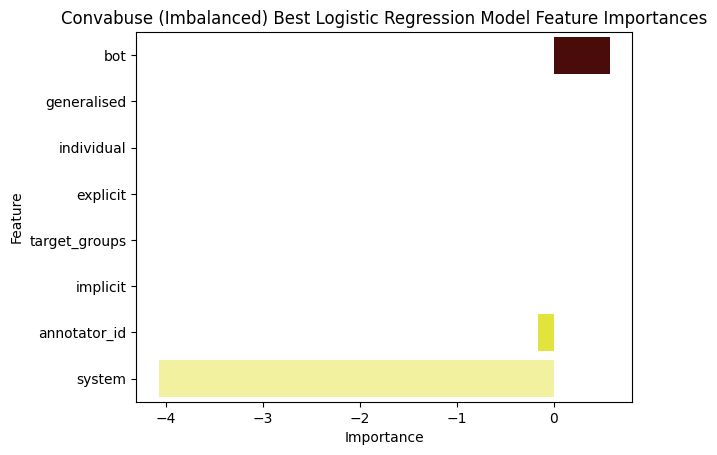

In [ ]:
# Plot the feature importances
sns.barplot(x="Importance", y="Feature", data=convabuse_feature_importances, palette="hot")
plt.title(f"Convabuse ({balance}) Best Logistic Regression Model Feature Importances")
plt.show()

In [ ]:
# Convert the feature importances to a dictionary
convabuse_feature_importances_dict = convabuse_feature_importances.set_index("Feature")["Importance"].to_dict()
logistic_regression_model_results.append(("Convabuse", convabuse_best_model_params["Regularizer"], convabuse_best_model_params["Solver"], convabuse_accuracy, convabuse_f1_score, 0.0, convabuse_feature_importances_dict))

## Dynamicaly Generated Hate Speech Logistic Regression

In [ ]:
dghs_results_list = []

# Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Dynamically Generated Hate Speech dataset
for regularizer in regularizers:
  for solver in solvers:
    if regularizer == "l1" and solver not in ["liblinear", "saga"]:
      continue
    dghs_logistic_regression = LogisticRegression(penalty=regularizer, solver=solver, random_state=42)
    dghs_logistic_regression.fit(dghs_X_train, dghs_y_train)
    # Predict the target variable for the test set
    dghs_y_pred = dghs_logistic_regression.predict(dghs_X_test)

    # Calculate the accuracy of the model
    dghs_accuracy = accuracy_score(dghs_y_test, dghs_y_pred)
    dghs_f1_score = f1_score(dghs_y_test, dghs_y_pred)
    dghs_results_list.append(("DGHS", regularizer, solver, dghs_accuracy, dghs_f1_score, 0))
    print(f"Regularizer: {regularizer}, Solver: {solver}, Accuracy: {dghs_accuracy}, F1-score: {dghs_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.827552515876893, F1-score: 0.8085683297180043
Regularizer: l1, Solver: saga, Accuracy: 0.827552515876893, F1-score: 0.8085683297180043
Regularizer: l2, Solver: lbfgs, Accuracy: 0.827552515876893, F1-score: 0.8085683297180043
Regularizer: l2, Solver: liblinear, Accuracy: 0.827552515876893, F1-score: 0.8085683297180043
Regularizer: l2, Solver: newton-cg, Accuracy: 0.827552515876893, F1-score: 0.8085683297180043
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.827552515876893, F1-score: 0.8085683297180043
Regularizer: l2, Solver: sag, Accuracy: 0.827552515876893, F1-score: 0.8085683297180043
Regularizer: l2, Solver: saga, Accuracy: 0.827552515876893, F1-score: 0.8085683297180043


In [ ]:
for ratio in l1_ratio_list:
    dghs_logistic_regression = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=ratio, random_state=42)
    dghs_logistic_regression.fit(dghs_X_train, dghs_y_train)
    # Predict the target variable for the test set
    dghs_y_pred = dghs_logistic_regression.predict(dghs_X_test)

    # Calculate the accuracy of the model
    dghs_accuracy = accuracy_score(dghs_y_test, dghs_y_pred)
    dghs_f1_score = f1_score(dghs_y_test, dghs_y_pred)
    dghs_results_list.append(("DGHS", "elasticnet", "saga", dghs_accuracy, dghs_f1_score, ratio))
    print(f"Regularizer: elasticnet, l1_ratio: {ratio}, Accuracy: {dghs_accuracy}, F1-score: {dghs_f1_score}")

Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.827552515876893, F1-score: 0.8085683297180043


In [ ]:
# Convert the results list into a dataframe
dghs_results = pd.DataFrame(dghs_results_list, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio"])
dghs_results

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,DGHS,l1,liblinear,0.827553,0.808568,0.0
1,DGHS,l1,saga,0.827553,0.808568,0.0
2,DGHS,l2,lbfgs,0.827553,0.808568,0.0
3,DGHS,l2,liblinear,0.827553,0.808568,0.0
4,DGHS,l2,newton-cg,0.827553,0.808568,0.0
5,DGHS,l2,newton-cholesky,0.827553,0.808568,0.0
6,DGHS,l2,sag,0.827553,0.808568,0.0
7,DGHS,l2,saga,0.827553,0.808568,0.0
8,DGHS,elasticnet,saga,0.827553,0.808568,0.5


In [ ]:
dghs_best_model_params = dghs_results.loc[dghs_results["Accuracy"].idxmax()]
dghs_best_model_params

,0
Dataset,DGHS
Regularizer,l1
Solver,liblinear
Accuracy,0.827553
F1-score,0.808568
Ratio,0.0


In [ ]:
# Use the best parameters to create a new best model
dghs_best_model = LogisticRegression(penalty=dghs_best_model_params["Regularizer"], solver=dghs_best_model_params["Solver"], random_state=42)
dghs_best_model.fit(dghs_X_train, dghs_y_train)

# Predict the target variable for the test set
dghs_y_pred = dghs_best_model.predict(dghs_X_test)

# Calculate the accuracy of the model
dghs_accuracy = accuracy_score(dghs_y_test, dghs_y_pred)
dghs_f1_score = f1_score(dghs_y_test, dghs_y_pred)

print(f"Regularizer: {dghs_best_model_params['Regularizer']}, Solver: {dghs_best_model_params['Solver']}, Accuracy: {dghs_accuracy}, F1-score: {dghs_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.827552515876893, F1-score: 0.8085683297180043


In [ ]:
# Get the best correlated feature with the target variable
dghs_best_correlated_feature = dghs_X_train.corrwith(dghs_y_train).abs().idxmax()
dghs_best_correlated_feature

'type'

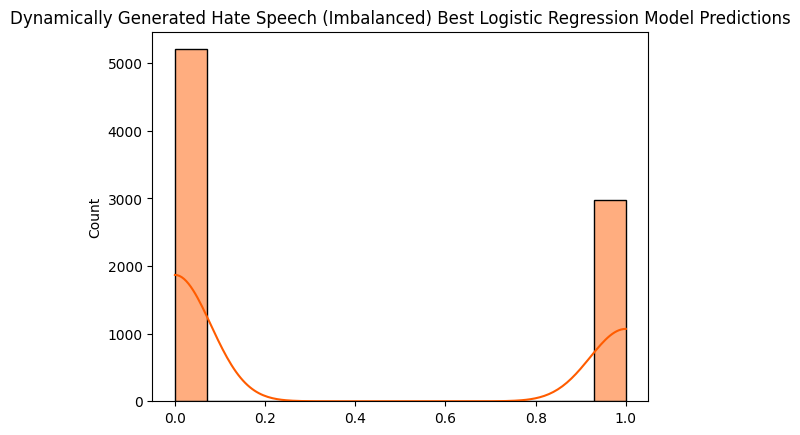

In [ ]:
# Plot the predictions that were generated as a histogram using seaborn colored by correct vs incorrect predictions
sns.histplot(dghs_y_pred, kde=True, palette='hot', color=middle_color)
plt.title(f"Dynamically Generated Hate Speech ({balance}) Best Logistic Regression Model Predictions")
plt.show()

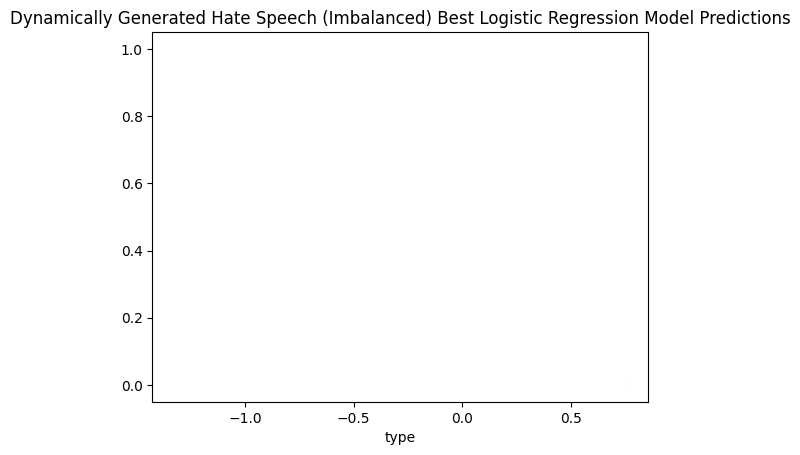

In [ ]:
# Plot the predictions that were generated as a scatterplot plotted against the best correlated feature
sns.scatterplot(x=dghs_X_test[dghs_best_correlated_feature], y=dghs_y_pred, c=dghs_y_test, cmap='hot')
plt.title(f"Dynamically Generated Hate Speech ({balance}) Best Logistic Regression Model Predictions")
plt.show()

In [ ]:
# Classification report for the best model
print(classification_report(dghs_y_test, dghs_y_pred))

              precision    recall  f1-score   support

         0.0       0.73      1.00      0.84      3794
         1.0       1.00      0.68      0.81      4394

    accuracy                           0.83      8188
   macro avg       0.86      0.84      0.83      8188
weighted avg       0.87      0.83      0.82      8188



In [ ]:
# Confusion matrix for the best model
dghs_confusion_matrix = pd.crosstab(dghs_y_test, dghs_y_pred, rownames=["Actual"], colnames=["Predicted"])
dghs_confusion_matrix

Predicted,0.0,1.0
Actual,,
0.0,3794,0
1.0,1412,2982


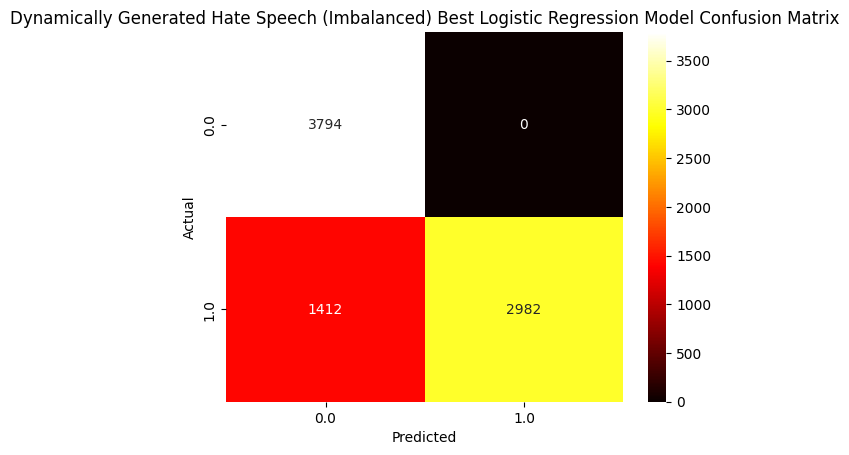

In [ ]:
# Heatmap to visualize the confusion matrix
sns.heatmap(dghs_confusion_matrix, annot=True, fmt="d", cmap="hot")
plt.title(f"Dynamically Generated Hate Speech ({balance}) Best Logistic Regression Model Confusion Matrix")
plt.show()

In [ ]:
# Calculate the feature importances
dghs_feature_importances = pd.DataFrame({"Feature": dghs_X_train.columns, "Importance": dghs_best_model.coef_[0]})
dghs_feature_importances = dghs_feature_importances.sort_values(by="Importance", ascending=False)
dghs_feature_importances

,Feature,Importance
3,original,3.880786
2,target_groups,0.157196
1,annotator,-0.223279
0,type,-8.143113


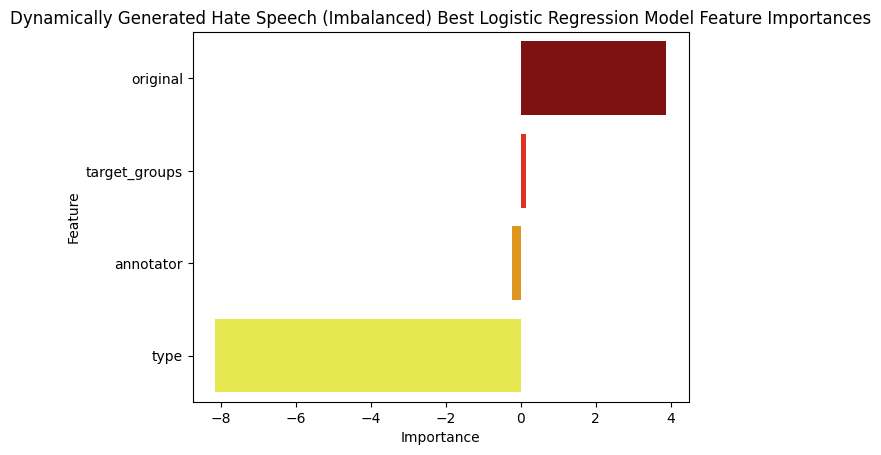

In [ ]:
# Plot the feature importances
sns.barplot(x="Importance", y="Feature", data=dghs_feature_importances, palette="hot")
plt.title(f"Dynamically Generated Hate Speech ({balance}) Best Logistic Regression Model Feature Importances")
plt.show()

In [ ]:
# Convert the feature importances to a dictionary
dghs_feature_importances_dict = dghs_feature_importances.set_index("Feature")["Importance"].to_dict()
logistic_regression_model_results.append(("DGHS", dghs_best_model_params["Regularizer"], dghs_best_model_params["Solver"], dghs_accuracy, dghs_f1_score, 0.0, dghs_feature_importances_dict))

In [ ]:
dghs_feature_importances_dict

{'original': 3.880785596630201,
 'target_groups': 0.15719619025410217,
 'annotator': -0.22327903224834003,
 'type': -8.143113097145054}

## Online Abusive Attacks Logistic Regression

In [ ]:
oaa_results_list = []

# Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Dynamically Generated Hate Speech dataset
for regularizer in regularizers:
  for solver in solvers:
    if regularizer == "l1" and solver not in ["liblinear", "saga"]:
      continue
    oaa_logistic_regression = LogisticRegression(penalty=regularizer, solver=solver, random_state=42)
    oaa_logistic_regression.fit(oaa_X_train, oaa_y_train)
    # Predict the target variable for the test set
    oaa_y_pred = oaa_logistic_regression.predict(oaa_X_test)

    # Calculate the accuracy of the model
    oaa_accuracy = accuracy_score(oaa_y_test, oaa_y_pred)
    oaa_f1_score = f1_score(oaa_y_test, oaa_y_pred, average="weighted")
    oaa_results_list.append(("DGHS", regularizer, solver, oaa_accuracy, oaa_f1_score, 0))
    print(f"Regularizer: {regularizer}, Solver: {solver}, Accuracy: {oaa_accuracy}, F1-score: {oaa_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.7926565874730022, F1-score: 0.746668917153419
Regularizer: l1, Solver: saga, Accuracy: 0.8120950323974082, F1-score: 0.800786763015756
Regularizer: l2, Solver: lbfgs, Accuracy: 0.8012958963282938, F1-score: 0.7871697968461353
Regularizer: l2, Solver: liblinear, Accuracy: 0.7041036717062635, F1-score: 0.6483560847242643
Regularizer: l2, Solver: newton-cg, Accuracy: 0.8012958963282938, F1-score: 0.7871697968461353
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.8012958963282938, F1-score: 0.7871697968461353
Regularizer: l2, Solver: sag, Accuracy: 0.7926565874730022, F1-score: 0.7780008902549959
Regularizer: l2, Solver: saga, Accuracy: 0.7818574514038877, F1-score: 0.7661925070135958


In [ ]:
for ratio in l1_ratio_list:
    oaa_logistic_regression = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=ratio, random_state=42)
    oaa_logistic_regression.fit(oaa_X_train, oaa_y_train)
    # Predict the target variable for the test set
    oaa_y_pred = oaa_logistic_regression.predict(oaa_X_test)

    # Calculate the accuracy of the model
    oaa_accuracy = accuracy_score(oaa_y_test, oaa_y_pred)
    oaa_f1_score = f1_score(oaa_y_test, oaa_y_pred, average="weighted")
    oaa_results_list.append(("DGHS", "elasticnet", "saga", oaa_accuracy, oaa_f1_score, ratio))
    print(f"Regularizer: elasticnet, l1_ratio: {ratio}, Accuracy: {oaa_accuracy}, F1-score: {oaa_f1_score}")

Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.7926565874730022, F1-score: 0.7780008902549959


In [ ]:
# Convert the results list into a dataframe
oaa_results = pd.DataFrame(oaa_results_list, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio"])
oaa_results

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,DGHS,l1,liblinear,0.792657,0.746669,0.0
1,DGHS,l1,saga,0.812095,0.800787,0.0
2,DGHS,l2,lbfgs,0.801296,0.787170,0.0
3,DGHS,l2,liblinear,0.704104,0.648356,0.0
4,DGHS,l2,newton-cg,0.801296,0.787170,0.0
5,DGHS,l2,newton-cholesky,0.801296,0.787170,0.0
6,DGHS,l2,sag,0.792657,0.778001,0.0
7,DGHS,l2,saga,0.781857,0.766193,0.0
8,DGHS,elasticnet,saga,0.792657,0.778001,0.5


In [ ]:
oaa_best_model_params = oaa_results.loc[oaa_results["Accuracy"].idxmax()]
oaa_best_model_params

,1
Dataset,DGHS
Regularizer,l1
Solver,saga
Accuracy,0.812095
F1-score,0.800787
Ratio,0.0


In [62]:
# Use the best parameters to create a new best model
oaa_best_model = LogisticRegression(penalty=oaa_best_model_params["Regularizer"], solver=oaa_best_model_params["Solver"], random_state=42)
oaa_best_model.fit(oaa_X_train, oaa_y_train)

# Predict the target variable for the test set
oaa_y_pred = oaa_best_model.predict(oaa_X_test)

# Calculate the accuracy of the model
oaa_accuracy = accuracy_score(oaa_y_test, oaa_y_pred)
oaa_f1_score = f1_score(oaa_y_test, oaa_y_pred, average="weighted")

print(f"Regularizer: {oaa_best_model_params['Regularizer']}, Solver: {oaa_best_model_params['Solver']}, Accuracy: {oaa_accuracy}, F1-score: {oaa_f1_score}")

Regularizer: l1, Solver: saga, Accuracy: 0.8120950323974082, F1-score: 0.800786763015756


In [63]:
# Get the best correlated feature with the target variable
oaa_best_correlated_feature = oaa_X_train.corrwith(oaa_y_train).abs().idxmax()
oaa_best_correlated_feature

'Toxic parent tweets'

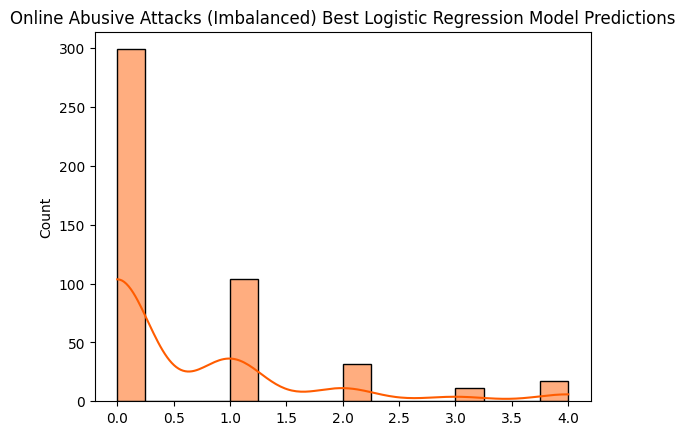

In [64]:
# Plot the predictions that were generated as a histogram using seaborn colored by correct vs incorrect predictions
sns.histplot(oaa_y_pred, kde=True, palette='hot', color=middle_color)
plt.title(f"Online Abusive Attacks ({balance}) Best Logistic Regression Model Predictions")
plt.show()

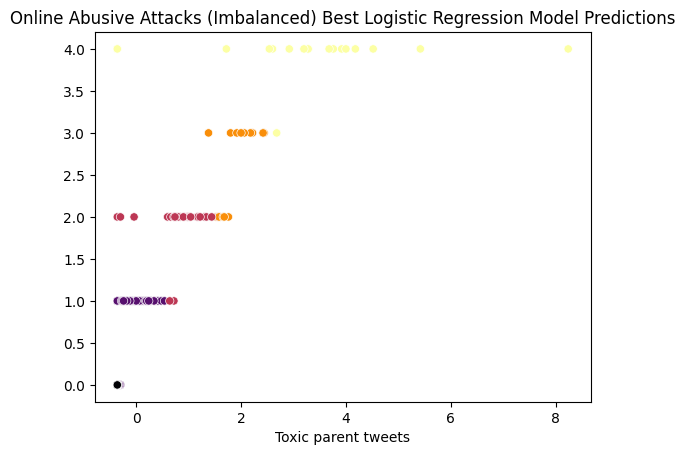

In [69]:
# Plot the predictions that were generated as a scatterplot plotted against the best correlated feature
sns.scatterplot(x=oaa_X_test[oaa_best_correlated_feature], y=oaa_y_pred, c=oaa_y_test, cmap='inferno')
plt.title(f"Online Abusive Attacks ({balance}) Best Logistic Regression Model Predictions")
plt.show()

In [70]:
# Classification report for the best model
print(classification_report(oaa_y_test, oaa_y_pred))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85       222
           1       0.96      0.56      0.71       177
           2       0.84      0.87      0.86        31
           3       0.91      0.67      0.77        15
           4       1.00      0.94      0.97        18

    accuracy                           0.81       463
   macro avg       0.89      0.81      0.83       463
weighted avg       0.85      0.81      0.80       463



In [71]:
# Confusion matrix for the best model
oaa_confusion_matrix = pd.crosstab(oaa_y_test, oaa_y_pred, rownames=["Actual"], colnames=["Predicted"])
oaa_confusion_matrix

Predicted,0,1,2,3,4
Actual,,,,,
0,222,0,0,0,0
1,77,100,0,0,0
2,0,4,27,0,0
3,0,0,5,10,0
4,0,0,0,1,17


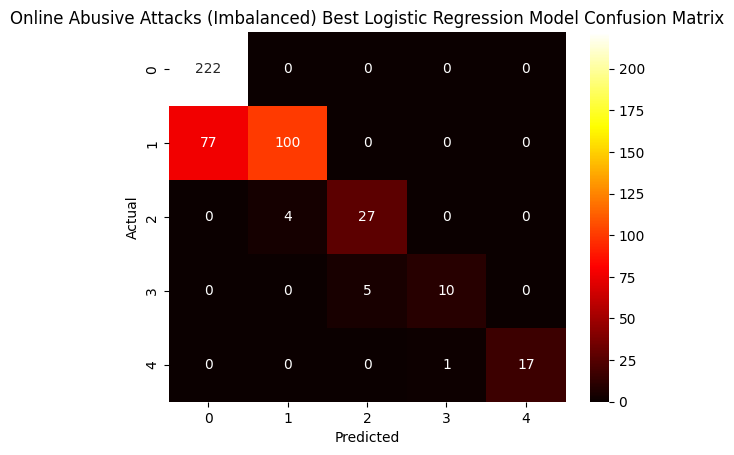

In [72]:
# Heatmap to visualize the confusion matrix
sns.heatmap(oaa_confusion_matrix, annot=True, fmt="d", cmap="hot")
plt.title(f"Online Abusive Attacks ({balance}) Best Logistic Regression Model Confusion Matrix")
plt.show()

In [73]:
# Calculate the feature importances
oaa_feature_importances = pd.DataFrame({"Feature": oaa_X_train.columns, "Importance": oaa_best_model.coef_[0]})
oaa_feature_importances = oaa_feature_importances.sort_values(by="Importance", ascending=False)
oaa_feature_importances

,Feature,Importance
1,Toxic replies,-6.170821
0,Toxic parent tweets,-14.100133


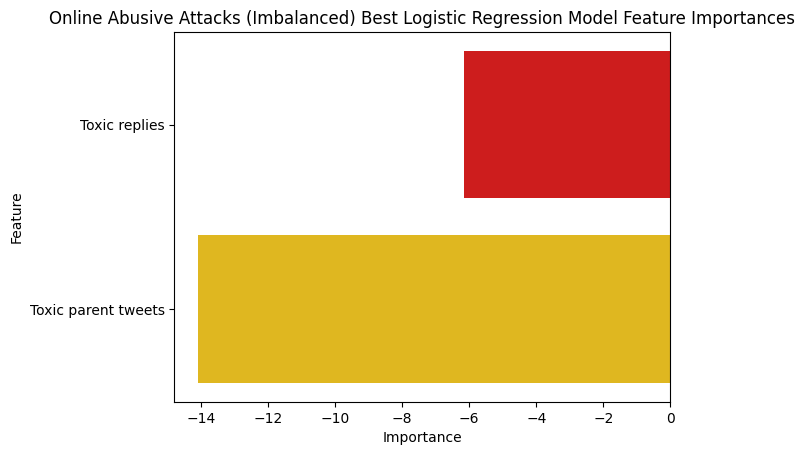

In [74]:
# Plot the feature importances
sns.barplot(x="Importance", y="Feature", data=oaa_feature_importances, palette="hot")
plt.title(f"Online Abusive Attacks ({balance}) Best Logistic Regression Model Feature Importances")
plt.show()

In [75]:
# Convert the feature importances to a dictionary
oaa_feature_importances_dict = oaa_feature_importances.set_index("Feature")["Importance"].to_dict()
logistic_regression_model_results.append(("Online Abusive Attacks", oaa_best_model_params["Regularizer"], oaa_best_model_params["Solver"], oaa_accuracy, oaa_f1_score, 0.0, oaa_feature_importances_dict))

In [76]:
oaa_feature_importances_dict

{'Toxic replies': -6.170820812897218,
 'Toxic parent tweets': -14.100133003555193}

## US Elections 2020 Hate Speech Logistic Regression

In [77]:
us2020hs_results_list = []

# Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Dynamically Generated Hate Speech dataset
for regularizer in regularizers:
  for solver in solvers:
    if regularizer == "l1" and solver not in ["liblinear", "saga"]:
      continue
    us2020hs_logistic_regression = LogisticRegression(penalty=regularizer, solver=solver, random_state=42)
    us2020hs_logistic_regression.fit(us2020hs_X_train, us2020hs_y_train)
    # Predict the target variable for the test set
    us2020hs_y_pred = us2020hs_logistic_regression.predict(us2020hs_X_test)

    # Calculate the accuracy of the model
    us2020hs_accuracy = accuracy_score(us2020hs_y_test, us2020hs_y_pred)
    us2020hs_f1_score = f1_score(us2020hs_y_test, us2020hs_y_pred)
    us2020hs_results_list.append(("US2020HS", regularizer, solver, us2020hs_accuracy, us2020hs_f1_score, 0))
    print(f"Regularizer: {regularizer}, Solver: {solver}, Accuracy: {us2020hs_accuracy}, F1-score: {us2020hs_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.8831385642737897, F1-score: 0.0
Regularizer: l1, Solver: saga, Accuracy: 0.8831385642737897, F1-score: 0.0
Regularizer: l2, Solver: lbfgs, Accuracy: 0.8831385642737897, F1-score: 0.0
Regularizer: l2, Solver: liblinear, Accuracy: 0.8831385642737897, F1-score: 0.0
Regularizer: l2, Solver: newton-cg, Accuracy: 0.8831385642737897, F1-score: 0.0
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.8831385642737897, F1-score: 0.0
Regularizer: l2, Solver: sag, Accuracy: 0.8831385642737897, F1-score: 0.0
Regularizer: l2, Solver: saga, Accuracy: 0.8831385642737897, F1-score: 0.0


In [78]:
for ratio in l1_ratio_list:
    us2020hs_logistic_regression = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=ratio, random_state=42)
    us2020hs_logistic_regression.fit(us2020hs_X_train, us2020hs_y_train)
    # Predict the target variable for the test set
    us2020hs_y_pred = us2020hs_logistic_regression.predict(us2020hs_X_test)

    # Calculate the accuracy of the model
    us2020hs_accuracy = accuracy_score(us2020hs_y_test, us2020hs_y_pred)
    us2020hs_f1_score = f1_score(us2020hs_y_test, us2020hs_y_pred)
    us2020hs_results_list.append(("US2020HS", "elasticnet", "saga", us2020hs_accuracy, us2020hs_f1_score, ratio))
    print(f"Regularizer: elasticnet, l1_ratio: {ratio}, Accuracy: {us2020hs_accuracy}, F1-score: {us2020hs_f1_score}")

Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.8831385642737897, F1-score: 0.0


In [79]:
# Convert the results list into a dataframe
us2020hs_results = pd.DataFrame(us2020hs_results_list, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio"])
us2020hs_results

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,US2020HS,l1,liblinear,0.883139,0.0,0.0
1,US2020HS,l1,saga,0.883139,0.0,0.0
2,US2020HS,l2,lbfgs,0.883139,0.0,0.0
3,US2020HS,l2,liblinear,0.883139,0.0,0.0
4,US2020HS,l2,newton-cg,0.883139,0.0,0.0
5,US2020HS,l2,newton-cholesky,0.883139,0.0,0.0
6,US2020HS,l2,sag,0.883139,0.0,0.0
7,US2020HS,l2,saga,0.883139,0.0,0.0
8,US2020HS,elasticnet,saga,0.883139,0.0,0.5


In [80]:
us2020hs_best_model_params = us2020hs_results.loc[us2020hs_results["Accuracy"].idxmax()]
us2020hs_best_model_params

,0
Dataset,US2020HS
Regularizer,l1
Solver,liblinear
Accuracy,0.883139
F1-score,0.0
Ratio,0.0


In [81]:
# Use the best parameters to create a new best model
us2020hs_best_model = LogisticRegression(penalty=us2020hs_best_model_params["Regularizer"], solver=us2020hs_best_model_params["Solver"], random_state=42)
us2020hs_best_model.fit(us2020hs_X_train, us2020hs_y_train)

# Predict the target variable for the test set
us2020hs_y_pred = us2020hs_best_model.predict(us2020hs_X_test)

# Calculate the accuracy of the best model
us2020hs_accuracy = accuracy_score(us2020hs_y_test, us2020hs_y_pred)
us2020hs_f1_score = f1_score(us2020hs_y_test, us2020hs_y_pred)

print(f"Regularizer: {us2020hs_best_model_params['Regularizer']}, Solver: {us2020hs_best_model_params['Solver']}, Accuracy: {us2020hs_accuracy}, F1-score: {us2020hs_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.8831385642737897, F1-score: 0.0


In [82]:
# Get the best correlated feature with the target variable
us2020hs_best_correlated_feature = us2020hs_X_train.corrwith(us2020hs_y_train).abs().idxmax()
us2020hs_best_correlated_feature

'Biden'

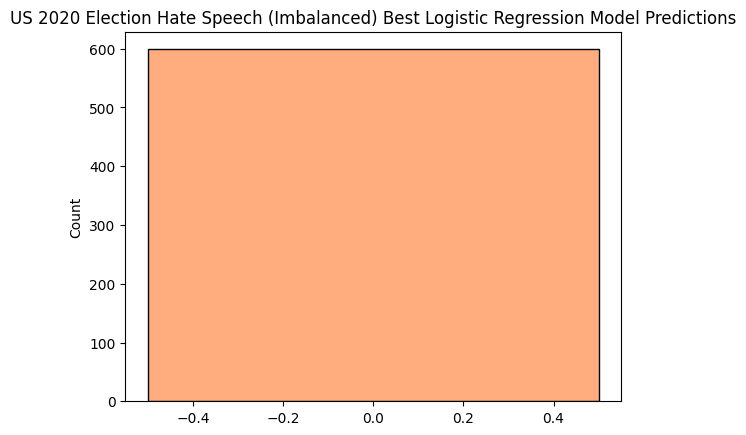

In [83]:
# Plot the predictions that were generated as a histogram using seaborn colored by correct vs incorrect predictions
sns.histplot(us2020hs_y_pred, kde=True, color=middle_color)
plt.title(f"US 2020 Election Hate Speech ({balance}) Best Logistic Regression Model Predictions")
plt.show()

In [84]:
# Classification report for the best model
print(classification_report(us2020hs_y_test, us2020hs_y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94       529
           1       0.00      0.00      0.00        70

    accuracy                           0.88       599
   macro avg       0.44      0.50      0.47       599
weighted avg       0.78      0.88      0.83       599



In [85]:
# Confusion matrix for the best model
us2020hs_confusion_matrix = pd.crosstab(us2020hs_y_test, us2020hs_y_pred, rownames=["Actual"], colnames=["Predicted"])
us2020hs_confusion_matrix

Predicted,0
Actual,
0,529
1,70


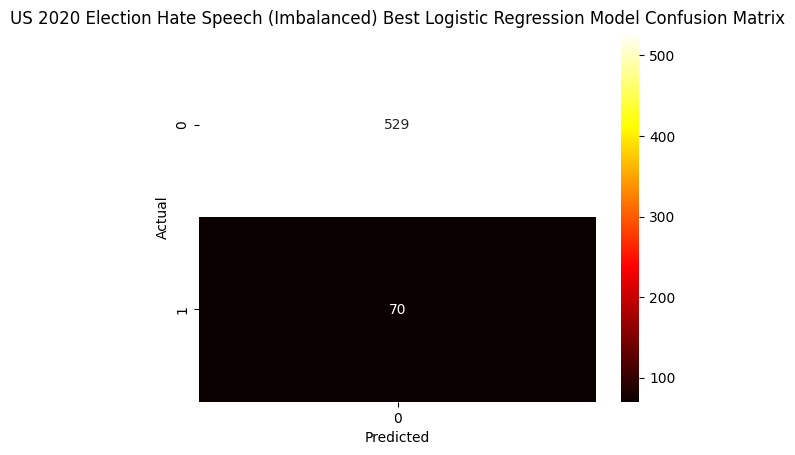

In [86]:
# Heatmap to visualize the confusion matrix
sns.heatmap(us2020hs_confusion_matrix, annot=True, fmt="d", cmap="hot")
plt.title(f"US 2020 Election Hate Speech ({balance}) Best Logistic Regression Model Confusion Matrix")
plt.show()

In [87]:
# Calculate the feature importances
us2020hs_feature_importances = pd.DataFrame({"Feature": us2020hs_X_train.columns, "Importance": us2020hs_best_model.coef_[0]})
us2020hs_feature_importances = us2020hs_feature_importances.sort_values(by="Importance", ascending=False)
us2020hs_feature_importances

,Feature,Importance
2,West,0.000000
0,Trump,-0.504745
1,Biden,-0.528653


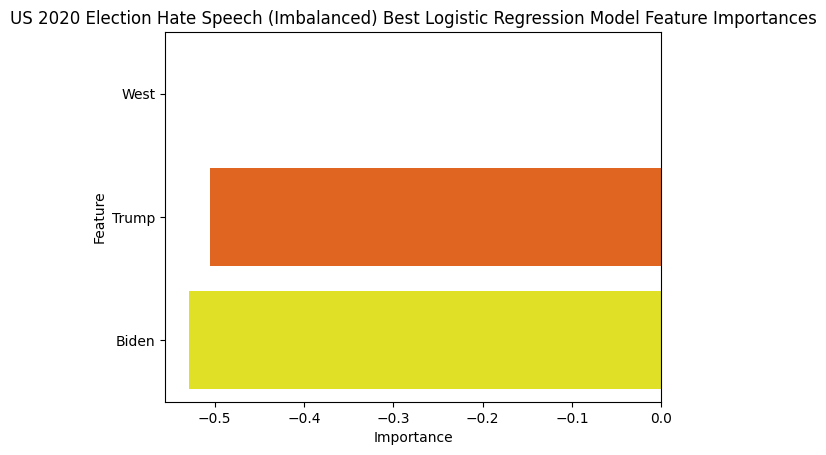

In [88]:
# Plot the feature importances
sns.barplot(x="Importance", y="Feature", data=us2020hs_feature_importances, palette="hot")
plt.title(f"US 2020 Election Hate Speech ({balance}) Best Logistic Regression Model Feature Importances")
plt.show()

In [89]:
# Convert the feature importances to a dictionary
us2020hs_feature_importances_dict = us2020hs_feature_importances.set_index("Feature")["Importance"].to_dict()
logistic_regression_model_results.append(("US2020HS", us2020hs_best_model_params["Regularizer"], us2020hs_best_model_params["Solver"], us2020hs_accuracy, us2020hs_f1_score, 0.0, us2020hs_feature_importances_dict))

## MLMA Hate Speech Logistic Regression

In [90]:
# Get a 10% sample of mlma_hate_speech_X_train
mlma_hate_speech_sample = mlma_hate_speech.sample(frac=0.3, random_state=42)

# Split into X and y
mlma_hate_speech_X_train_sample = mlma_hate_speech_sample.drop("target_groups", axis=1)
mlma_hate_speech_y_train_sample = mlma_hate_speech_sample["target_groups"]

# StandardScaler
mlma_hate_speech_X_train_scaled_sample = mlma_hate_speech_scaler.fit_transform(mlma_hate_speech_X_train_sample)
mlma_hate_speech_X_train_scaled_sample = pd.DataFrame(mlma_hate_speech_X_train_sample, columns=mlma_hate_speech_X_train.columns)

# Train-test-split
mlma_hate_speech_X_train_sample, mlma_hate_speech_X_test_sample, mlma_hate_speech_y_train_sample, mlma_hate_speech_y_test_sample = train_test_split(mlma_hate_speech_X_train_scaled_sample, mlma_hate_speech_y_train_sample, test_size=0.2, random_state=42)

In [91]:
mlma_hate_speech_results_list = []

# Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Dynamically Generated Hate Speech dataset
for solver in ["liblinear", "saga"]:
  mlma_hate_speech_logistic_regression = LogisticRegression(penalty="l1", solver=solver, random_state=42)
  mlma_hate_speech_logistic_regression.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)
  # Predict the target variable for the test set
  mlma_hate_speech_y_pred = mlma_hate_speech_logistic_regression.predict(mlma_hate_speech_X_test_sample)

  # Calculate the accuracy of the model
  mlma_hate_speech_accuracy = accuracy_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred)
  mlma_hate_speech_f1_score = f1_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred, average='weighted')
  mlma_hate_speech_results_list.append(("MLMA Hate Speech", "l1", solver, mlma_hate_speech_accuracy, mlma_hate_speech_f1_score, 0))
  print(f"Regularizer: l1, Solver: {solver}, Accuracy: {mlma_hate_speech_accuracy}, F1-score: {mlma_hate_speech_f1_score}")

Regularizer: l1, Solver: liblinear, Accuracy: 0.5881818181818181, F1-score: 0.47622177122035386
Regularizer: l1, Solver: saga, Accuracy: 0.5963636363636363, F1-score: 0.49657903806491527


In [92]:
# Use logistic regression with L1, L2, and ElasticNet regularization with standardized features of the Dynamically Generated Hate Speech dataset
for solver in solvers:
  if solver in ["liblinear", "saga"]:
    mlma_hate_speech_logistic_regression = LogisticRegression(penalty="l1", solver=solver, random_state=42)
  else:
    mlma_hate_speech_logistic_regression = LogisticRegression(penalty="l2", solver=solver, random_state=42)
  mlma_hate_speech_logistic_regression.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)
  # Predict the target variable for the test set
  mlma_hate_speech_y_pred = mlma_hate_speech_logistic_regression.predict(mlma_hate_speech_X_test_sample)

  # Calculate the accuracy of the model
  mlma_hate_speech_accuracy = accuracy_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred)
  mlma_hate_speech_f1_score = f1_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred, average='weighted')
  mlma_hate_speech_results_list.append(("MLMA Hate Speech", mlma_hate_speech_logistic_regression.penalty, solver, mlma_hate_speech_accuracy, mlma_hate_speech_f1_score, 0))
  print(f"Regularizer: {mlma_hate_speech_logistic_regression.penalty}, Solver: {solver}, Accuracy: {mlma_hate_speech_accuracy}, F1-score: {mlma_hate_speech_f1_score}")

Regularizer: l2, Solver: lbfgs, Accuracy: 0.5963636363636363, F1-score: 0.49657903806491527
Regularizer: l1, Solver: liblinear, Accuracy: 0.5881818181818181, F1-score: 0.47622177122035386
Regularizer: l2, Solver: newton-cg, Accuracy: 0.5963636363636363, F1-score: 0.49657903806491527
Regularizer: l2, Solver: newton-cholesky, Accuracy: 0.5963636363636363, F1-score: 0.49657903806491527
Regularizer: l2, Solver: sag, Accuracy: 0.5963636363636363, F1-score: 0.49657903806491527
Regularizer: l1, Solver: saga, Accuracy: 0.5963636363636363, F1-score: 0.49657903806491527


In [93]:
for ratio in l1_ratio_list:
    mlma_hate_speech_logistic_regression = LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=ratio, random_state=42)
    mlma_hate_speech_logistic_regression.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)
    # Predict the target variable for the test set
    mlma_hate_speech_y_pred = mlma_hate_speech_logistic_regression.predict(mlma_hate_speech_X_test_sample)

    # Calculate the accuracy of the model
    mlma_hate_speech_accuracy = accuracy_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred)
    mlma_hate_speech_f1_score = f1_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred, average='weighted')
    mlma_hate_speech_results_list.append(("MLMA Hate Speech", "elasticnet", "saga", mlma_hate_speech_accuracy, mlma_hate_speech_f1_score, ratio))
    print(f"Regularizer: elasticnet, l1_ratio: {ratio}, Accuracy: {mlma_hate_speech_accuracy}, F1-score: {mlma_hate_speech_f1_score}")

Regularizer: elasticnet, l1_ratio: 0.5, Accuracy: 0.5963636363636363, F1-score: 0.49657903806491527


In [94]:
# Convert the results list into a dataframe
mlma_hate_speech_results = pd.DataFrame(mlma_hate_speech_results_list, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio"])
mlma_hate_speech_results

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio
0,MLMA Hate Speech,l1,liblinear,0.588182,0.476222,0.0
1,MLMA Hate Speech,l1,saga,0.596364,0.496579,0.0
2,MLMA Hate Speech,l2,lbfgs,0.596364,0.496579,0.0
3,MLMA Hate Speech,l1,liblinear,0.588182,0.476222,0.0
4,MLMA Hate Speech,l2,newton-cg,0.596364,0.496579,0.0
5,MLMA Hate Speech,l2,newton-cholesky,0.596364,0.496579,0.0
6,MLMA Hate Speech,l2,sag,0.596364,0.496579,0.0
7,MLMA Hate Speech,l1,saga,0.596364,0.496579,0.0
8,MLMA Hate Speech,elasticnet,saga,0.596364,0.496579,0.5


In [95]:
mlma_hate_speech_best_model_params = mlma_hate_speech_results.loc[mlma_hate_speech_results["Accuracy"].idxmax()]
mlma_hate_speech_best_model_params

,1
Dataset,MLMA Hate Speech
Regularizer,l1
Solver,saga
Accuracy,0.596364
F1-score,0.496579
Ratio,0.0


In [96]:
# Use the best parameters to create a new best model
mlma_hate_speech_best_model = LogisticRegression(penalty=mlma_hate_speech_best_model_params["Regularizer"], solver=mlma_hate_speech_best_model_params["Solver"], random_state=42)
mlma_hate_speech_best_model.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)

# Predict the target variable for the test set
mlma_hate_speech_y_pred = mlma_hate_speech_best_model.predict(mlma_hate_speech_X_test_sample)

# Calculate the accuracy of the best model
mlma_hate_speech_accuracy = accuracy_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred)
mlma_hate_speech_f1_score = f1_score(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred, average="weighted")

print(f"Regularizer: {mlma_hate_speech_best_model_params['Regularizer']}, Solver: {mlma_hate_speech_best_model_params['Solver']}, Accuracy: {mlma_hate_speech_accuracy}, F1-score: {mlma_hate_speech_f1_score}")

Regularizer: l1, Solver: saga, Accuracy: 0.5963636363636363, F1-score: 0.49657903806491527


In [97]:
logistic_regression_model_results

[('Convabuse',
  'l1',
  'liblinear',
  0.8855325914149443,
  0.8520266948557892,
  0.0,
  {'bot': 0.5777202483608284,
   'generalised': 0.0,
   'individual': 0.0,
   'explicit': 0.0,
   'target_groups': 0.0,
   'implicit': 0.0,
   'annotator_id': -0.15955663967799974,
   'system': -4.069397075951528}),
 ('DGHS',
  'l1',
  'liblinear',
  0.827552515876893,
  0.8085683297180043,
  0.0,
  {'original': 3.880785596630201,
   'target_groups': 0.15719619025410217,
   'annotator': -0.22327903224834003,
   'type': -8.143113097145054}),
 ('Online Abusive Attacks',
  'l1',
  'saga',
  0.8120950323974082,
  0.800786763015756,
  0.0,
  {'Toxic replies': -6.170820812897218,
   'Toxic parent tweets': -14.100133003555193}),
 ('US2020HS',
  'l1',
  'liblinear',
  0.8831385642737897,
  0.0,
  0.0,
  {'West': 0.0, 'Trump': -0.5047453980305149, 'Biden': -0.5286527299147836})]

In [98]:
# Get the best correlated feature with the target variable
mlma_hate_speech_best_correlated_feature = mlma_hate_speech_X_train.corrwith(mlma_hate_speech_y_train).abs().idxmax()
mlma_hate_speech_best_correlated_feature

'sadness_annotator_sentiment'

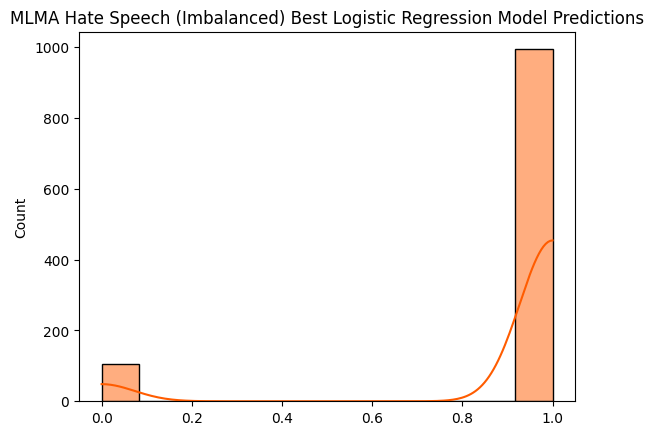

In [99]:
sns.histplot(mlma_hate_speech_y_pred, kde=True, color=middle_color)
plt.title(f"MLMA Hate Speech ({balance}) Best Logistic Regression Model Predictions")
plt.show()

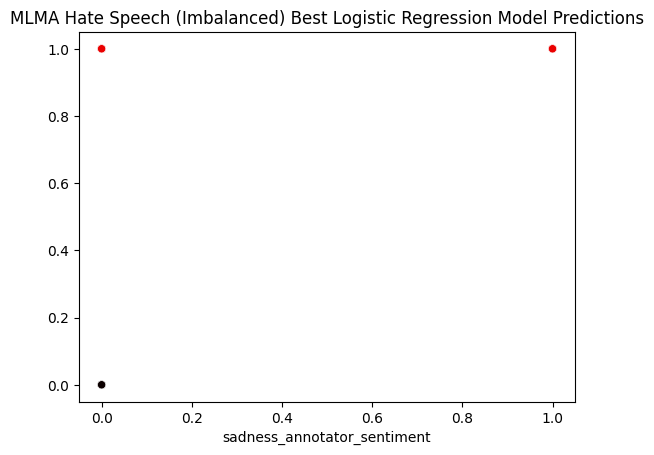

In [100]:
# Plot the predictions that were generated as a scatterplot plotted against the best correlated feature
sns.scatterplot(x=mlma_hate_speech_X_test_sample[mlma_hate_speech_best_correlated_feature], y=mlma_hate_speech_y_pred, c=mlma_hate_speech_y_test_sample, cmap='hot')
plt.title(f"MLMA Hate Speech ({balance}) Best Logistic Regression Model Predictions")
plt.show()

In [101]:
# Classification report for the best model
print(classification_report(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred))

              precision    recall  f1-score   support

           0       0.57      0.26      0.35       233
           1       0.60      0.94      0.73       633
           2       0.00      0.00      0.00       198
           3       0.00      0.00      0.00        36

    accuracy                           0.60      1100
   macro avg       0.29      0.30      0.27      1100
weighted avg       0.46      0.60      0.50      1100



In [102]:
# Confusion matrix for the best model
mlma_hate_speech_confusion_matrix = pd.crosstab(mlma_hate_speech_y_test_sample, mlma_hate_speech_y_pred, rownames=["Actual"], colnames=["Predicted"])
mlma_hate_speech_confusion_matrix

Predicted,0,1
Actual,,
0,60,173
1,37,596
2,8,190
3,1,35


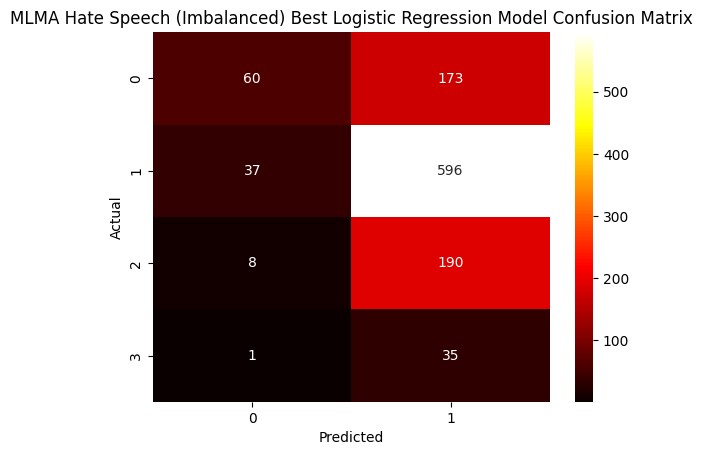

In [103]:
# Heatmap to visualize the confusion matrix
sns.heatmap(mlma_hate_speech_confusion_matrix, annot=True, fmt="d", cmap="hot")
plt.title(f"MLMA Hate Speech ({balance}) Best Logistic Regression Model Confusion Matrix")
plt.show()

In [104]:
# Calculate the feature importances
mlma_hate_speech_feature_importances = pd.DataFrame({"Feature": mlma_hate_speech_X_train_sample.columns, "Importance": mlma_hate_speech_best_model.coef_[0]})
mlma_hate_speech_feature_importances = mlma_hate_speech_feature_importances.sort_values(by="Importance", ascending=False)
mlma_hate_speech_feature_importances

,Feature,Importance
10,Not Abusive,0.337293
4,indifference_annotator_sentiment,0.228034
7,implicit,0.152240
8,explicit,-0.036159
11,Very Abusive,-0.093556
9,Abusive,-0.184818
12,Very Strongly Abusive,-0.209613
0,shock_annotator_sentiment,-0.225465
5,disgust_annotator_sentiment,-0.356160
2,confusion_annotator_sentiment,-0.419676


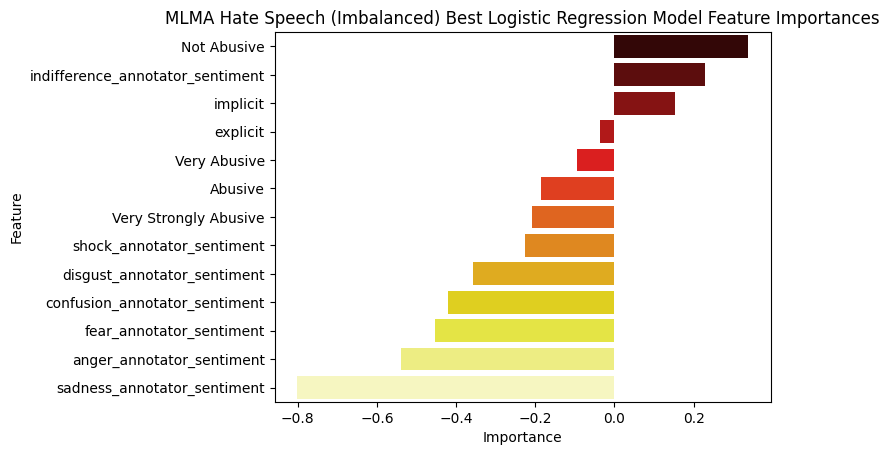

In [105]:
# Plot the feature importances
sns.barplot(x="Importance", y="Feature", data=mlma_hate_speech_feature_importances, palette="hot")
plt.title(f"MLMA Hate Speech ({balance}) Best Logistic Regression Model Feature Importances")
plt.show()

In [106]:
# Convert the feature importances to a dictionary
mlma_hate_speech_feature_importances_dict = mlma_hate_speech_feature_importances.set_index("Feature")["Importance"].to_dict()
logistic_regression_model_results.append(("MLMA Hate Speech", mlma_hate_speech_best_model_params["Regularizer"], mlma_hate_speech_best_model_params["Solver"], mlma_hate_speech_accuracy, mlma_hate_speech_f1_score, 0.0, mlma_hate_speech_feature_importances_dict))

## Logistic Regression Conclusions

In [107]:
logistic_regression_model_results

[('Convabuse',
  'l1',
  'liblinear',
  0.8855325914149443,
  0.8520266948557892,
  0.0,
  {'bot': 0.5777202483608284,
   'generalised': 0.0,
   'individual': 0.0,
   'explicit': 0.0,
   'target_groups': 0.0,
   'implicit': 0.0,
   'annotator_id': -0.15955663967799974,
   'system': -4.069397075951528}),
 ('DGHS',
  'l1',
  'liblinear',
  0.827552515876893,
  0.8085683297180043,
  0.0,
  {'original': 3.880785596630201,
   'target_groups': 0.15719619025410217,
   'annotator': -0.22327903224834003,
   'type': -8.143113097145054}),
 ('Online Abusive Attacks',
  'l1',
  'saga',
  0.8120950323974082,
  0.800786763015756,
  0.0,
  {'Toxic replies': -6.170820812897218,
   'Toxic parent tweets': -14.100133003555193}),
 ('US2020HS',
  'l1',
  'liblinear',
  0.8831385642737897,
  0.0,
  0.0,
  {'West': 0.0, 'Trump': -0.5047453980305149, 'Biden': -0.5286527299147836}),
 ('MLMA Hate Speech',
  'l1',
  'saga',
  0.5963636363636363,
  0.49657903806491527,
  0.0,
  {'Not Abusive': 0.3372934904240555,


In [108]:
# Combine the two results sets into a single logistic regression model summary
logistic_regression_model_summary = pd.concat([convabuse_results, dghs_results, oaa_results, us2020hs_results, mlma_hate_speech_results], ignore_index=True)
logistic_regression_model_summary["Balance"] = "Imbalanced"
logistic_regression_model_summary

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio,Balance
0,Convabuse,l1,liblinear,0.885533,0.852027,0.0,Imbalanced
1,Convabuse,l1,saga,0.885533,0.852027,0.0,Imbalanced
2,Convabuse,l2,lbfgs,0.885533,0.852027,0.0,Imbalanced
3,Convabuse,l2,liblinear,0.885533,0.852027,0.0,Imbalanced
4,Convabuse,l2,newton-cg,0.885533,0.852027,0.0,Imbalanced
5,Convabuse,l2,newton-cholesky,0.885533,0.852027,0.0,Imbalanced
6,Convabuse,l2,sag,0.885533,0.852027,0.0,Imbalanced
7,Convabuse,l2,saga,0.885533,0.852027,0.0,Imbalanced
8,Convabuse,elasticnet,saga,0.885533,0.852027,0.5,Imbalanced
9,DGHS,l1,liblinear,0.827553,0.808568,0.0,Imbalanced


In [109]:
# Convert to a dataframe
logistic_regression_model_results = pd.DataFrame(logistic_regression_model_results, columns=["Dataset", "Regularizer", "Solver", "Accuracy", "F1-score", "Ratio", "Feature Importances"])
logistic_regression_model_results["Balance"] = "Imbalanced"
logistic_regression_model_results["Model"] = "Logistic Regression"
logistic_regression_model_results

,Dataset,Regularizer,Solver,Accuracy,F1-score,Ratio,Feature Importances,Balance,Model
0,Convabuse,l1,liblinear,0.885533,0.852027,0.0,"{'bot': 0.5777202483608284, 'generalised': 0.0...",Imbalanced,Logistic Regression
1,DGHS,l1,liblinear,0.827553,0.808568,0.0,"{'original': 3.880785596630201, 'target_groups...",Imbalanced,Logistic Regression
2,Online Abusive Attacks,l1,saga,0.812095,0.800787,0.0,"{'Toxic replies': -6.170820812897218, 'Toxic p...",Imbalanced,Logistic Regression
3,US2020HS,l1,liblinear,0.883139,0.000000,0.0,"{'West': 0.0, 'Trump': -0.5047453980305149, 'B...",Imbalanced,Logistic Regression
4,MLMA Hate Speech,l1,saga,0.596364,0.496579,0.0,"{'Not Abusive': 0.3372934904240555, 'indiffere...",Imbalanced,Logistic Regression


In [110]:
logistic_regression_model_results.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/model4_logistic-regression-summary_imbalanced.csv", index=False)